# Bayesian Q-Learning on the Noisy Bandit

Training run demonstrating VPI-driven exploration on a K-armed Gaussian bandit.
We compare Bayesian Q-learning against ε-greedy and Thompson sampling baselines.

In [32]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from environments import NoisyBandit
from bayesian_qlearning import BayesianQLearning, NormalGamma

rng = np.random.default_rng(42)
np.random.seed(42)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Environment

Config : 'easy' — 5-arm, σ≈0.6, gap=0.7, SNR≈1.0 (original)
K=5 arms  |  optimal arm=2  |  optimal mean=1.50  |  2nd-best mean=1.00  |  gap=0.50  |  noise σ=0.5  |  SNR=1.00  |  N_STEPS=1000  |  WINDOW=50


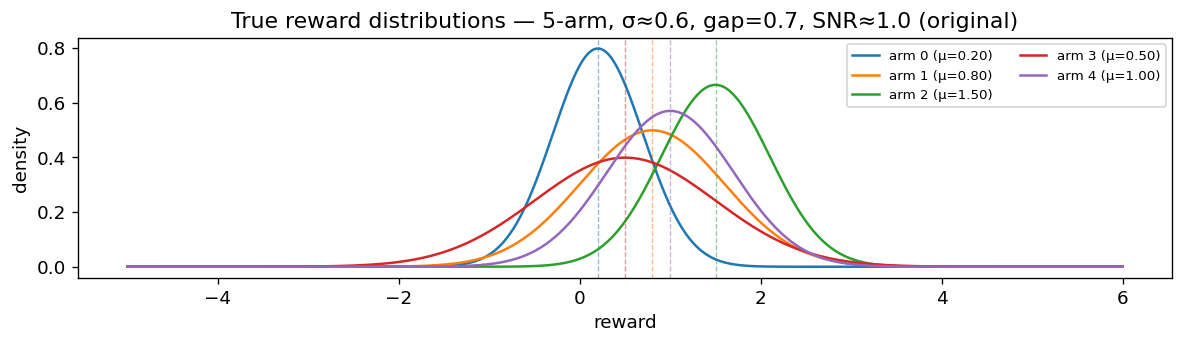

In [33]:
# ── Bandit configuration toggle ──────────────────────────────────────────────
# Set BANDIT = "easy"  →  5-arm original task  (σ≈0.6, gap=0.7, SNR≈1.0)
#     BANDIT = "hard"  →  10-arm harder task   (σ=1.5,  gap=0.3, SNR≈0.2)
BANDIT = "easy"

CONFIGS = {
    "easy": dict(
        means   = np.array([0.2, 0.8, 1.5, 0.5, 1.0]),
        stds    = np.array([0.5, 0.8, 0.6, 1.0, 0.7]),
        n_steps = 1_000,
        window  = 50,
        description = "5-arm, σ≈0.6, gap=0.7, SNR≈1.0 (original)",
    ),
    "hard": dict(
        means   = np.array([0.50, 0.60, 0.55, 0.65, 0.50, 0.70, 0.60, 1.00, 0.55, 0.65]),
        stds    = np.array([1.50] * 10),
        n_steps = 2_000,
        window  = 100,
        description = "10-arm, σ=1.5, gap=0.3, SNR≈0.2 (hard)",
    ),
}

cfg     = CONFIGS[BANDIT]
MEANS   = cfg["means"]
STDS    = cfg["stds"]
K       = len(MEANS)
N_STEPS = cfg["n_steps"]
WINDOW  = cfg["window"]

env = NoisyBandit(means=MEANS, stds=STDS)
print(f"Config : {BANDIT!r} — {cfg['description']}")
print(f"K={K} arms  |  optimal arm={env.optimal_action}  |  optimal mean={MEANS[env.optimal_action]:.2f}"
      f"  |  2nd-best mean={np.sort(MEANS)[-2]:.2f}  |  gap={MEANS[env.optimal_action]-np.sort(MEANS)[-2]:.2f}"
      f"  |  noise σ={STDS[0]:.1f}  |  SNR={(MEANS[env.optimal_action]-np.sort(MEANS)[-2])/STDS[0]:.2f}"
      f"  |  N_STEPS={N_STEPS}  |  WINDOW={WINDOW}")

# Quick visual of true reward distributions
fig, ax = plt.subplots(figsize=(10, 3))
x = np.linspace(-5, 6, 600)
for k in range(K):
    pdf = stats.norm.pdf(x, loc=MEANS[k], scale=STDS[k])
    ax.plot(x, pdf, label=f"arm {k} (μ={MEANS[k]:.2f})")
    ax.axvline(MEANS[k], color=f"C{k}", lw=0.8, ls="--", alpha=0.5)
ax.set(xlabel="reward", ylabel="density",
       title=f"True reward distributions — {cfg['description']}")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Baseline agents

In [34]:
class EpsilonGreedy:
    """Sample-mean estimates with ε-greedy exploration."""

    def __init__(self, n_actions: int, epsilon: float = 0.1):
        self.n_actions = n_actions
        self.epsilon = epsilon
        self._counts = np.zeros(n_actions)
        self._means  = np.zeros(n_actions)

    def select_action(self, state: int = 0) -> int:
        if np.random.random() < self.epsilon:
            return int(np.random.randint(self.n_actions))
        return int(np.argmax(self._means))

    def update(self, state: int, action: int, reward: float,
               next_state: int, done: bool) -> None:
        self._counts[action] += 1
        self._means[action] += (reward - self._means[action]) / self._counts[action]

    def greedy_action(self, state: int = 0) -> int:
        return int(np.argmax(self._means))


class ThompsonSampling:
    """Thompson sampling via Normal-Gamma posteriors (same prior as Bayesian Q)."""

    def __init__(self, n_actions: int, mu0=0.0, lam0=1.0, alpha0=1.0, beta0=1.0):
        self.n_actions = n_actions
        prior = NormalGamma(mu=mu0, lam=lam0, alpha=alpha0, beta=beta0)
        self._posteriors = [prior for _ in range(n_actions)]

    def select_action(self, state: int = 0) -> int:
        samples = [p.sample() for p in self._posteriors]
        return int(np.argmax(samples))

    def update(self, state: int, action: int, reward: float,
               next_state: int, done: bool) -> None:
        self._posteriors[action] = self._posteriors[action].update(reward)

    def greedy_action(self, state: int = 0) -> int:
        return int(np.argmax([p.mean for p in self._posteriors]))

## Training loop

In [35]:
def run_bandit(agent, env: NoisyBandit, n_steps: int):
    """Run agent on bandit for n_steps; return per-step logs."""
    state = env.reset()
    rewards      = np.zeros(n_steps)
    actions      = np.zeros(n_steps, dtype=int)
    optimal_hits = np.zeros(n_steps, dtype=bool)
    opt = env.optimal_action

    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        rewards[t]      = r
        actions[t]      = a
        optimal_hits[t] = (a == opt)
        state = next_state

    return rewards, actions, optimal_hits


N_SEEDS = 20      # independent runs for confidence intervals
OPT     = env.optimal_action

agents_cfg = {
    # "Bayesian Q (VPI)":  lambda: BayesianQLearning(n_states=1, n_actions=K,
                                                    # gamma=0.0,
                                                    # mu0=0.0, lam0=1.0, alpha0=1.0, beta0=1.0),
    "Thompson sampling": lambda: ThompsonSampling(n_actions=K),
    "ε-greedy (ε=0.1)":  lambda: EpsilonGreedy(n_actions=K, epsilon=0.1),
    # "ε-greedy (ε=0.01)": lambda: EpsilonGreedy(n_actions=K, epsilon=0.01),
}

results = {}  # name -> {"rewards": (n_seeds, n_steps), "optimal": (n_seeds, n_steps)}

for name, make_agent in agents_cfg.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = make_agent()
        r, a, opt_hits = run_bandit(agent, env, N_STEPS)
        all_r.append(r)
        all_opt.append(opt_hits)
    results[name] = {
        "rewards": np.array(all_r),
        "optimal": np.array(all_opt, dtype=float),
    }
    mean_r = results[name]["rewards"].mean()
    mean_o = results[name]["optimal"].mean() * 100
    print(f"{name:<24}  avg reward={mean_r:.3f}  optimal%={mean_o:.1f}")

Thompson sampling         avg reward=1.460  optimal%=95.6
ε-greedy (ε=0.1)          avg reward=1.400  optimal%=87.4


## Learning curves

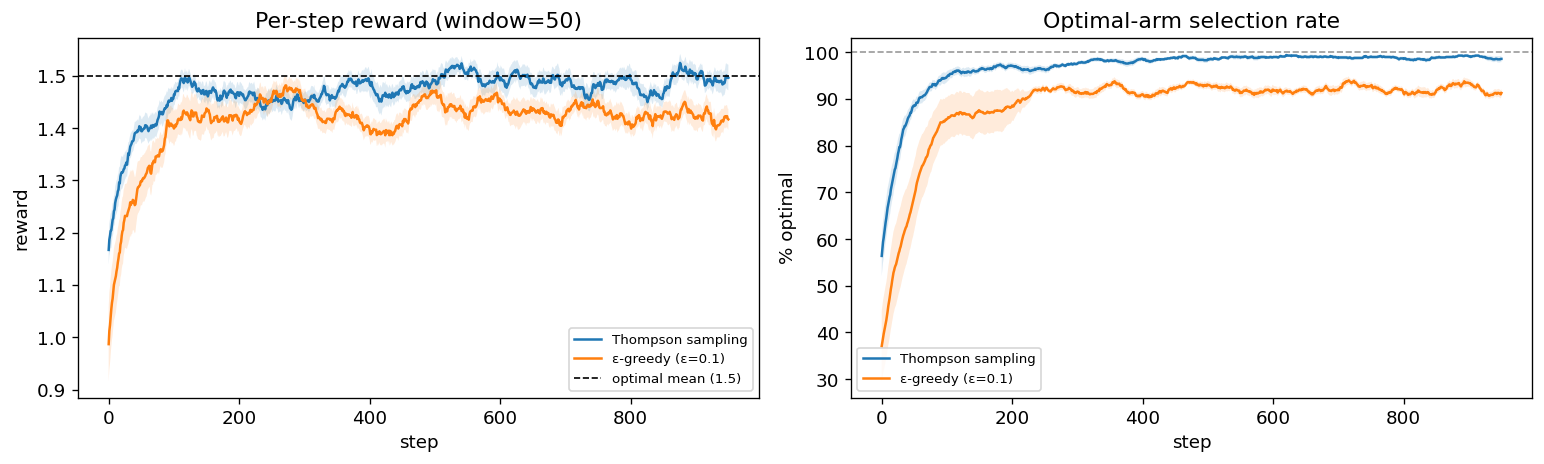

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, data in results.items():
    r   = data["rewards"]    # (n_seeds, n_steps)
    opt = data["optimal"]    # (n_seeds, n_steps)

    def smooth(x):
        return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")

    r_sm   = np.array([smooth(row) for row in r])
    opt_sm = np.array([smooth(row) for row in opt])
    steps  = np.arange(r_sm.shape[1])

    for ax, y, ylabel in zip(axes,
                              [r_sm, opt_sm * 100],
                              ["Reward (smoothed)", "% optimal action (smoothed)"]):
        mu  = y.mean(0)
        sem = y.std(0) / np.sqrt(N_SEEDS)
        ax.plot(steps, mu, label=name)
        ax.fill_between(steps, mu - sem, mu + sem, alpha=0.15)

axes[0].axhline(MEANS[OPT], ls="--", color="k", lw=1, label=f"optimal mean ({MEANS[OPT]})")
axes[0].set(xlabel="step", ylabel="reward", title=f"Per-step reward (window={WINDOW})")
axes[0].legend(fontsize=8)

axes[1].axhline(100, ls="--", color="k", lw=1, alpha=0.4)
axes[1].set(xlabel="step", ylabel="% optimal", title="Optimal-arm selection rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Cumulative regret

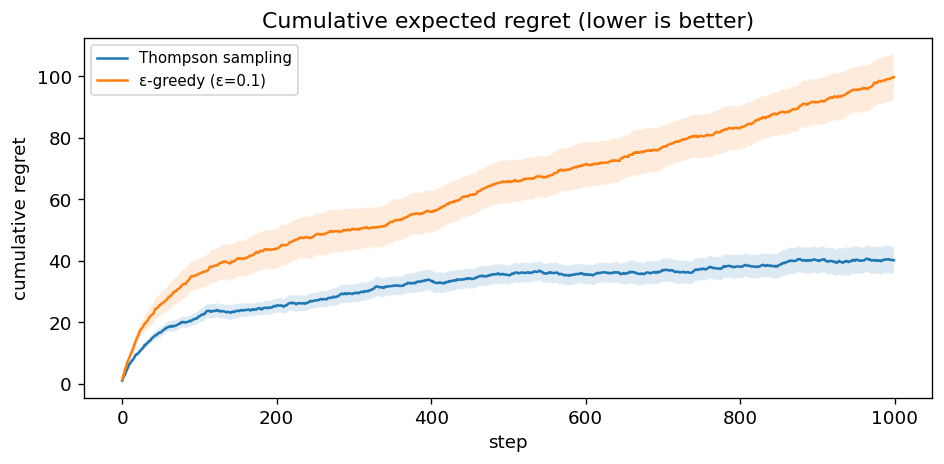

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, data in results.items():
    # instantaneous regret = optimal_mean - observed_reward
    regret = MEANS[OPT] - data["rewards"]           # (n_seeds, n_steps)
    cum_regret = regret.cumsum(axis=1)
    mu  = cum_regret.mean(0)
    sem = cum_regret.std(0) / np.sqrt(N_SEEDS)
    ax.plot(mu, label=name)
    ax.fill_between(np.arange(N_STEPS), mu - sem, mu + sem, alpha=0.15)

ax.set(xlabel="step", ylabel="cumulative regret",
       title="Cumulative expected regret (lower is better)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Posterior evolution of Bayesian Q-learning (single seed)

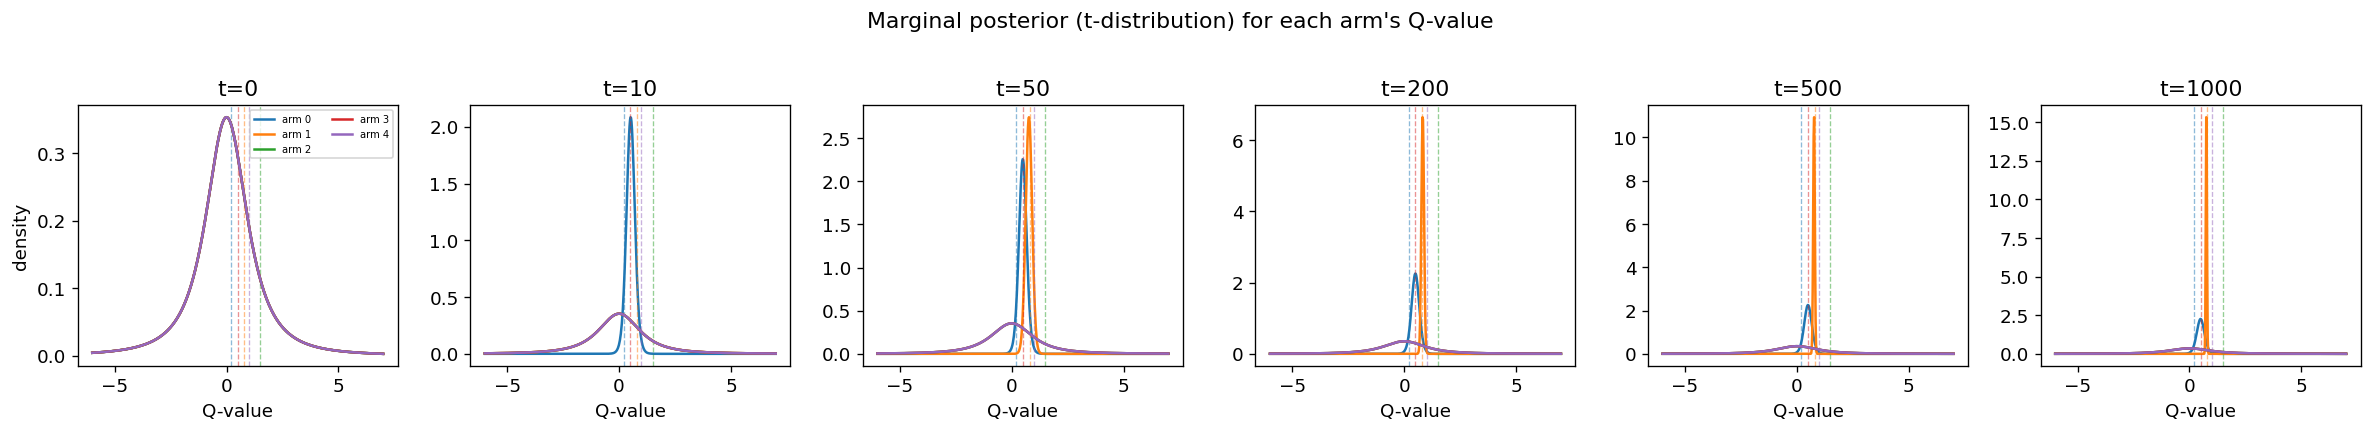

In [38]:
def run_bandit_logged(agent, env, n_steps, snapshot_steps):
    """Like run_bandit but also saves posterior snapshots at given steps."""
    state = env.reset()
    rewards, actions, optimal_hits = [], [], []
    snapshots = {}  # step -> list of NormalGamma (one per arm)
    opt = env.optimal_action

    for t in range(n_steps):
        if t in snapshot_steps:
            snapshots[t] = [agent.q_params(0, a) for a in range(agent.n_actions)]
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        rewards.append(r)
        actions.append(a)
        optimal_hits.append(a == opt)
        state = next_state

    snapshots[n_steps] = [agent.q_params(0, a) for a in agent.n_actions
                          ] if False else [agent.q_params(0, a) for a in range(agent.n_actions)]
    return np.array(rewards), np.array(actions), np.array(optimal_hits), snapshots


np.random.seed(0)
bql_agent = BayesianQLearning(n_states=1, n_actions=K, gamma=0.0)
SNAP_STEPS = {0, 10, 50, 200, 500, 1000, 1999}
r_log, a_log, opt_log, snapshots = run_bandit_logged(bql_agent, env, N_STEPS, SNAP_STEPS)

# plot posterior t-distributions at each snapshot
snap_sorted = sorted(snapshots.keys())
fig, axes = plt.subplots(1, len(snap_sorted), figsize=(20, 3.5), sharey=False)
x = np.linspace(-6, 7, 600)

for ax, t in zip(axes, snap_sorted):
    for k, ng in enumerate(snapshots[t]):
        pdf = stats.t.pdf(x, df=ng.df, loc=ng.mu, scale=ng.scale)
        ax.plot(x, pdf, color=f"C{k}", label=f"arm {k}")
        ax.axvline(MEANS[k], color=f"C{k}", lw=0.8, ls="--", alpha=0.5)
    ax.set_title(f"t={t}")
    ax.set_xlabel("Q-value")
    if ax is axes[0]:
        ax.set_ylabel("density")
        ax.legend(fontsize=6, ncol=2)

fig.suptitle("Marginal posterior (t-distribution) for each arm's Q-value", y=1.02)
plt.tight_layout()
plt.show()

## VPI and action-selection anatomy (single seed)

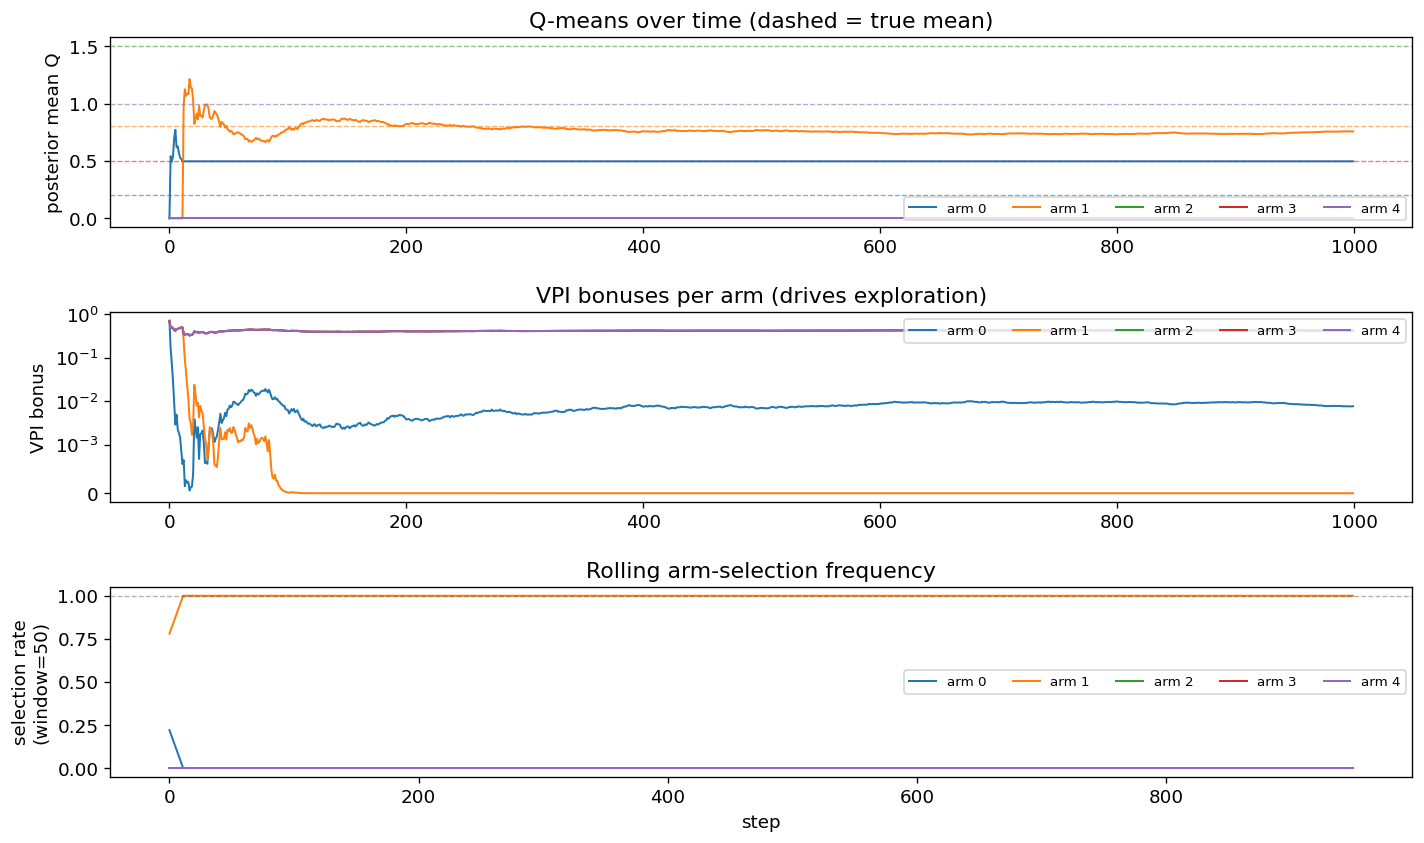

In [39]:
def run_bandit_vpi_log(env, n_steps, seed=0):
    """Single seed: log per-step Q-means, VPI bonuses, and chosen actions."""
    np.random.seed(seed)
    agent = BayesianQLearning(n_states=1, n_actions=K, gamma=0.0)
    state = env.reset()

    q_means_log  = np.zeros((n_steps, K))
    vpi_log      = np.zeros((n_steps, K))
    actions_log  = np.zeros(n_steps, dtype=int)

    for t in range(n_steps):
        means = agent.q_means(0)
        vpis  = np.array([agent.vpi(0, a) for a in range(K)])
        q_means_log[t] = means
        vpi_log[t]     = vpis

        a = int(np.argmax(means + vpis))
        actions_log[t] = a
        _, r, done, _ = env.step(a)
        agent.update(0, a, r, 0, done)
        state = 0

    return q_means_log, vpi_log, actions_log


q_means_log, vpi_log, actions_log = run_bandit_vpi_log(env, N_STEPS)

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# --- top: Q-means with true means as dashed lines
ax0 = fig.add_subplot(gs[0])
for k in range(K):
    ax0.plot(q_means_log[:, k], label=f"arm {k}", color=f"C{k}", lw=1.2)
    ax0.axhline(MEANS[k], ls="--", color=f"C{k}", lw=0.8, alpha=0.6)
ax0.set(ylabel="posterior mean Q", title="Q-means over time (dashed = true mean)")
ax0.legend(ncol=K, fontsize=8, loc="lower right")

# --- middle: VPI bonuses
ax1 = fig.add_subplot(gs[1])
for k in range(K):
    ax1.plot(vpi_log[:, k], label=f"arm {k}", color=f"C{k}", lw=1.2)
ax1.set(ylabel="VPI bonus", title="VPI bonuses per arm (drives exploration)")
ax1.legend(ncol=K, fontsize=8, loc="upper right")
ax1.set_yscale("symlog", linthresh=1e-3)

# --- bottom: action selection raster (rolling 50-step fraction)
ax2 = fig.add_subplot(gs[2])
win = 50
for k in range(K):
    frac = np.convolve((actions_log == k).astype(float),
                       np.ones(win) / win, mode="valid")
    ax2.plot(frac, label=f"arm {k}", color=f"C{k}", lw=1.2)
ax2.axhline(1.0, ls="--", color="k", lw=0.8, alpha=0.3)
ax2.set(xlabel="step", ylabel=f"selection rate\n(window={win})",
        title="Rolling arm-selection frequency")
ax2.legend(ncol=K, fontsize=8, loc="center right")

plt.show()

## Prior sensitivity

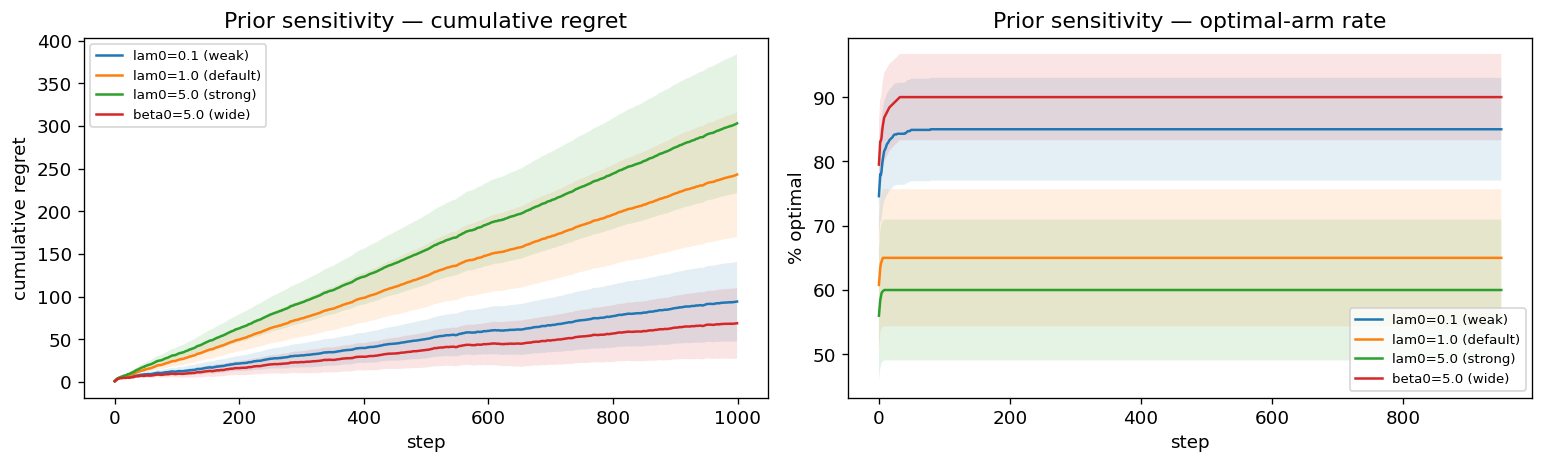

In [40]:
prior_cfgs = {
    "lam0=0.1 (weak)":   dict(lam0=0.1,  alpha0=1.0, beta0=1.0),
    "lam0=1.0 (default)": dict(lam0=1.0,  alpha0=1.0, beta0=1.0),
    "lam0=5.0 (strong)":  dict(lam0=5.0,  alpha0=1.0, beta0=1.0),
    "beta0=5.0 (wide)":   dict(lam0=1.0,  alpha0=1.0, beta0=5.0),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, kwargs in prior_cfgs.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = BayesianQLearning(n_states=1, n_actions=K, gamma=0.0, mu0=0.0, **kwargs)
        r, _, opt_hits = run_bandit(agent, env, N_STEPS)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))

    r_arr   = np.array(all_r)
    opt_arr = np.array(all_opt)

    cum_regret = (MEANS[OPT] - r_arr).cumsum(axis=1)
    mu_reg = cum_regret.mean(0)
    sem_reg = cum_regret.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(mu_reg, label=label)
    axes[0].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg, alpha=0.12)

    def smooth(x): return np.convolve(x, np.ones(WINDOW)/WINDOW, mode="valid")
    opt_sm = np.array([smooth(row) for row in opt_arr]) * 100
    mu_opt = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    steps = np.arange(opt_sm.shape[1])
    axes[1].plot(steps, mu_opt, label=label)
    axes[1].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt, alpha=0.12)

axes[0].set(xlabel="step", ylabel="cumulative regret", title="Prior sensitivity — cumulative regret")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="step", ylabel="% optimal", title="Prior sensitivity — optimal-arm rate")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Diagnosis: arm-pull counts and early exploration

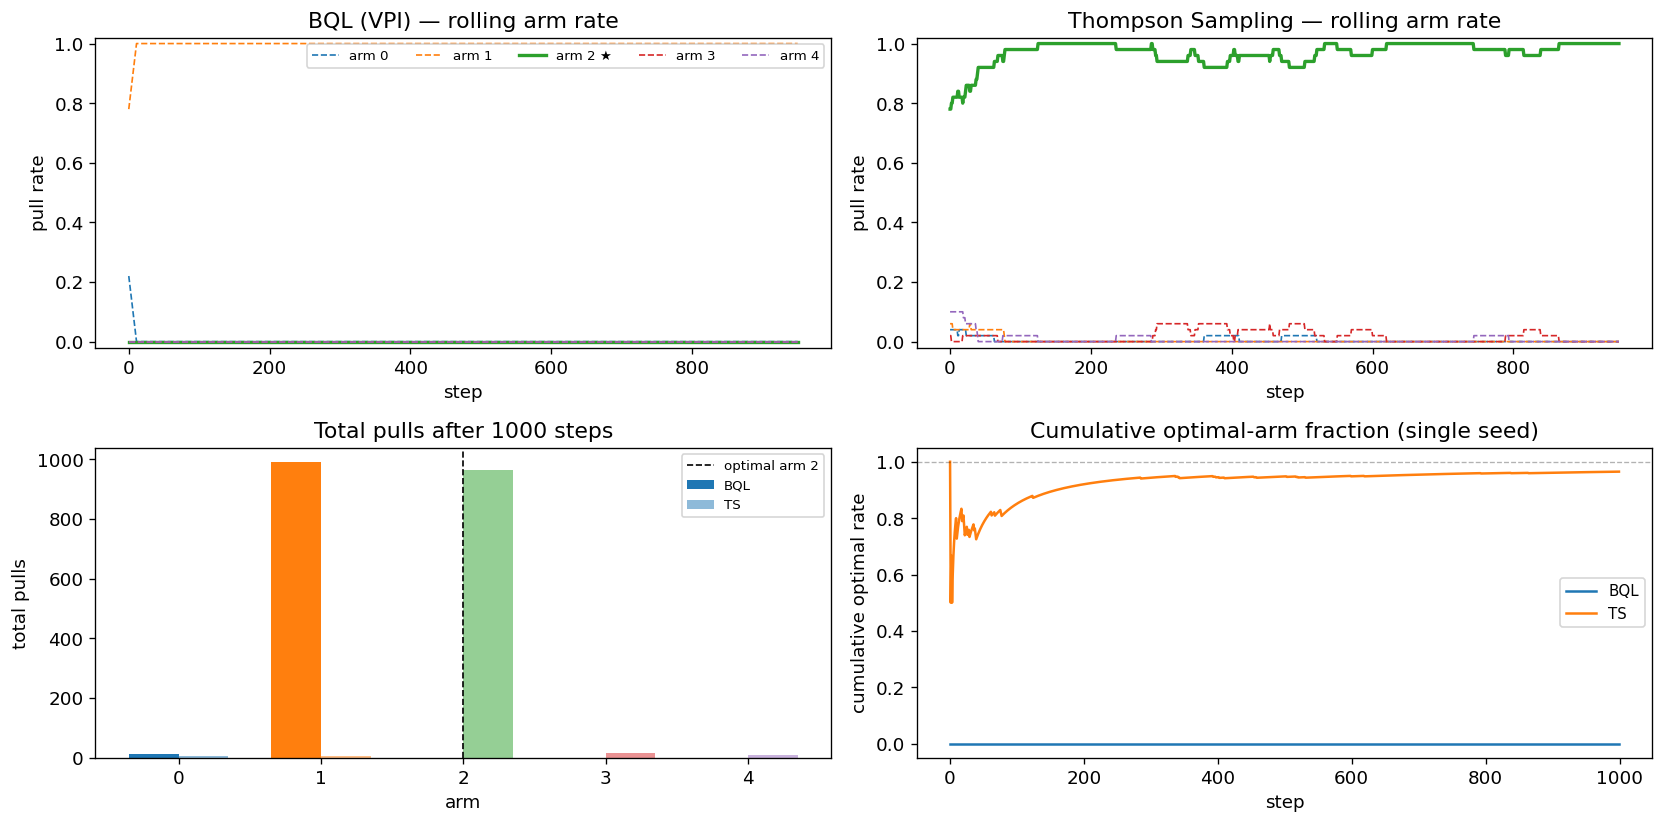


Total pulls per arm  (BQL) : [ 11 989   0   0   0]
Total pulls per arm  (TS)  : [  5   5 965  17   8]

BQL optimal arm fraction: 0.000
TS  optimal arm fraction: 0.965


In [41]:
def run_bandit_with_counts(agent, env, n_steps, seed=0):
    """Return per-step arm counts and cumulative optimal-arm rate."""
    np.random.seed(seed)
    state = env.reset()
    arm_counts = np.zeros((n_steps, K), dtype=int)
    opt = env.optimal_action
    cum_opt = np.zeros(n_steps)

    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        arm_counts[t, a] = 1
        cum_opt[t] = (a == opt)
        state = next_state

    return arm_counts, cum_opt


# Single-seed arm pull counts for BQL and Thompson Sampling (same seed, same env)
np.random.seed(0)
bql_count_agent = BayesianQLearning(n_states=1, n_actions=K, gamma=0.0)
bql_counts, bql_cum_opt = run_bandit_with_counts(bql_count_agent, env, N_STEPS, seed=0)

np.random.seed(0)
ts_count_agent = ThompsonSampling(n_actions=K)
ts_counts, ts_cum_opt = run_bandit_with_counts(ts_count_agent, env, N_STEPS, seed=0)

# Rolling pull rate (window=50)
def rolling_arm_rates(counts, win=50):
    rolled = np.array([np.convolve(counts[:, k], np.ones(win)/win, mode="valid")
                       for k in range(K)]).T
    return rolled

bql_rates = rolling_arm_rates(bql_counts)
ts_rates  = rolling_arm_rates(ts_counts)
steps_r   = np.arange(bql_rates.shape[0])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
opt_color = [f"C{k}" for k in range(K)]

# -- row 0: rolling arm rates
for k in range(K):
    lw = 2.0 if k == OPT else 1.0
    ls = "-" if k == OPT else "--"
    axes[0, 0].plot(steps_r, bql_rates[:, k], color=f"C{k}", lw=lw, ls=ls,
                    label=f"arm {k}" + (" ★" if k == OPT else ""))
    axes[0, 1].plot(steps_r, ts_rates[:, k], color=f"C{k}", lw=lw, ls=ls)

for ax, title in zip(axes[0], ["BQL (VPI) — rolling arm rate",
                                 "Thompson Sampling — rolling arm rate"]):
    ax.set(xlabel="step", ylabel="pull rate", title=title, ylim=(-0.02, 1.02))

axes[0, 0].legend(fontsize=8, ncol=K)

# -- row 1: cumulative counts as bar at end of training
total_bql = bql_counts.sum(0)
total_ts  = ts_counts.sum(0)
x = np.arange(K)
w = 0.35
axes[1, 0].bar(x - w/2, total_bql, w, color=[f"C{k}" for k in range(K)], label="BQL")
axes[1, 0].bar(x + w/2, total_ts,  w, color=[f"C{k}" for k in range(K)], alpha=0.5, label="TS")
axes[1, 0].axvline(OPT, color="k", ls="--", lw=1, label=f"optimal arm {OPT}")
axes[1, 0].set(xlabel="arm", ylabel="total pulls", title=f"Total pulls after {N_STEPS} steps")
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_xticks(x)

# -- cumulative optimal-arm rate over time
axes[1, 1].plot(np.cumsum(bql_cum_opt) / np.arange(1, N_STEPS+1), label="BQL", lw=1.5)
axes[1, 1].plot(np.cumsum(ts_cum_opt)  / np.arange(1, N_STEPS+1), label="TS",  lw=1.5)
axes[1, 1].set(xlabel="step", ylabel="cumulative optimal rate",
               title="Cumulative optimal-arm fraction (single seed)")
axes[1, 1].axhline(1.0, ls="--", color="k", lw=0.8, alpha=0.3)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal pulls per arm  (BQL) : {total_bql}")
print(f"Total pulls per arm  (TS)  : {total_ts}")
print(f"\nBQL optimal arm fraction: {total_bql[OPT]/N_STEPS:.3f}")
print(f"TS  optimal arm fraction: {total_ts[OPT]/N_STEPS:.3f}")

## Why VPI underperforms Thompson sampling on the bandit

Three factors combine:

1. **Deterministic tie-breaking at t=0**: all arms have the same initial score (~0.707), so `argmax` always picks arm 0 first. Arm 0 is over-represented in early exploration regardless of its true value.

2. **Sequential, one-arm-at-a-time exploration**: VPI asks "which *single* experiment gives the most information right now?" It focuses on one arm until that arm's uncertainty collapses, then moves to the next. This is optimal for a one-shot information-gathering problem, but in a cumulative-reward bandit you pay regret the entire time you're exploring a sub-optimal arm.

3. **Myopic horizon**: The Dearden VPI is a one-step look-ahead. It does not account for the long-run value of learning about multiple arms simultaneously. Thompson sampling implicitly does this: it draws from all posteriors jointly and naturally allocates pulls proportional to P(arm k is optimal), achieving near-optimal Lai–Robbins regret bounds.

**Two targeted fixes below**:
- **Fix A — random tie-breaking**: shuffles the initial symmetry so arm 0 is no longer always explored first.
- **Fix B — optimistic initialization**: sets `mu0` above the plausible reward range so all arms start looking equally valuable; exploration is forced before the algorithm can exploit.

In [47]:
class BQLRandomTies(BayesianQLearning):
    """BQL with uniform random tie-breaking in select_action."""

    def select_action(self, state: int) -> int:
        means = self.q_means(state)
        vpi_bonuses = np.array([self.vpi(state, a) for a in range(self.n_actions)])
        scores = means + vpi_bonuses
        # break ties randomly by adding a tiny Gumbel perturbation
        scores = scores + np.random.gumbel(0, 1e-9, size=scores.shape)
        return int(np.argmax(scores))


agents_fixed = {
    "BQL (VPI) — original":       lambda: BayesianQLearning(n_states=1, n_actions=K, gamma=0.0),
    "BQL — Fix A (random ties)":  lambda: BQLRandomTies(n_states=1, n_actions=K, gamma=0.0),
    "BQL — Fix B (mu0=2.0)":      lambda: BayesianQLearning(n_states=1, n_actions=K, gamma=0.0,
                                                             mu0=2.0, lam0=1.0, alpha0=1.0, beta0=1.0),
    "BQL — Fix A+B":              lambda: BQLRandomTies(n_states=1, n_actions=K, gamma=0.0,
                                                        mu0=2.0, lam0=1.0, alpha0=1.0, beta0=1.0),
    "Thompson sampling":          lambda: ThompsonSampling(n_actions=K),
}

fixed_results = {}
for name, make in agents_fixed.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = make()
        r, _, opt_hits = run_bandit(agent, env, N_STEPS)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))
    fixed_results[name] = {"rewards": np.array(all_r), "optimal": np.array(all_opt)}
    mean_o = fixed_results[name]["optimal"].mean() * 100
    cum_r  = (MEANS[OPT] - fixed_results[name]["rewards"]).sum(1).mean()
    print(f"{name:<38}  optimal%={mean_o:.1f}  cumulative regret={cum_r:.1f}")

BQL (VPI) — original                    optimal%=64.8  cumulative regret=243.2
BQL — Fix A (random ties)               optimal%=59.7  cumulative regret=258.5
BQL — Fix B (mu0=2.0)                   optimal%=98.9  cumulative regret=13.1
BQL — Fix A+B                           optimal%=98.8  cumulative regret=0.8
Thompson sampling                       optimal%=95.6  cumulative regret=40.2


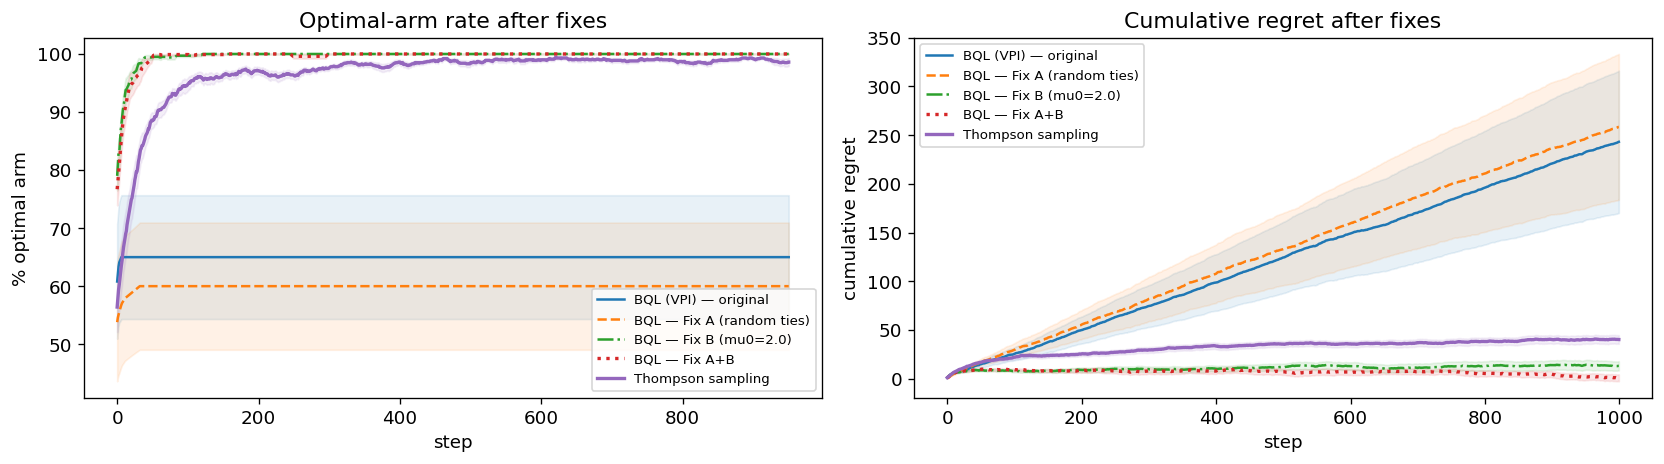

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

STYLES = {
    "BQL (VPI) — original":       ("C0", "-",  1.5),
    "BQL — Fix A (random ties)":  ("C1", "--", 1.5),
    "BQL — Fix B (mu0=2.0)":      ("C2", "-.", 1.5),
    "BQL — Fix A+B":              ("C3", ":",  2.0),
    "Thompson sampling":          ("C4", "-",  2.0),
}

for name, data in fixed_results.items():
    color, ls, lw = STYLES[name]
    r   = data["rewards"]
    opt = data["optimal"]

    def smooth(x): return np.convolve(x, np.ones(WINDOW)/WINDOW, mode="valid")
    opt_sm = np.array([smooth(row) for row in opt]) * 100
    steps  = np.arange(opt_sm.shape[1])

    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, color=color, ls=ls, lw=lw, label=name)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt, color=color, alpha=0.1)

    cum_reg = (MEANS[OPT] - r).cumsum(1)
    mu_reg  = cum_reg.mean(0)
    sem_reg = cum_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_reg, color=color, ls=ls, lw=lw, label=name)
    axes[1].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg,
                         color=color, alpha=0.1)

axes[0].set(xlabel="step", ylabel="% optimal arm", title="Optimal-arm rate after fixes")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="step", ylabel="cumulative regret", title="Cumulative regret after fixes")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Replay buffer augmentation

In [49]:
from replay_buffer import ReplayBuffer

def run_bandit_replay(agent, env: NoisyBandit, n_steps: int,
                      replay_every: int, replay_n: int,
                      buffer_capacity: int):
    """Like run_bandit but every `replay_every` steps also replays
    `replay_n` random experiences from a circular buffer of size
    `buffer_capacity`.

    Note: replaying pushes additional observations through the same
    `agent.update` path, so conjugate posteriors accumulate more
    pseudo-counts than raw steps alone.  This accelerates convergence
    at the cost of some over-confidence, analogous to experience replay
    in deep RL.
    """
    buf   = ReplayBuffer(capacity=buffer_capacity)
    state = env.reset()
    opt   = env.optimal_action

    rewards      = np.zeros(n_steps)
    actions      = np.zeros(n_steps, dtype=int)
    optimal_hits = np.zeros(n_steps, dtype=bool)

    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)

        agent.update(state, a, r, next_state, done)
        buf.push(state, a, r, next_state, done)

        if (t + 1) % replay_every == 0 and len(buf) > 0:
            buf.replay_into(agent, replay_n)

        rewards[t]      = r
        actions[t]      = a
        optimal_hits[t] = (a == opt)
        state           = next_state

    return rewards, actions, optimal_hits


REPLAY_EVERY = 10   # replay frequency (steps)
REPLAY_N     = 10   # experiences sampled per replay
BUF_CAPACITY = 500  # circular buffer size

print(f"Replay every {REPLAY_EVERY} steps, sampling {REPLAY_N} experiences "
      f"from a buffer of {BUF_CAPACITY}.")

Replay every 10 steps, sampling 10 experiences from a buffer of 500.


In [50]:
replay_agents_cfg = {
    # ---- without replay ----
    # "BQL (no replay)":             (lambda: BayesianQLearning(n_states=1, n_actions=K, gamma=0.0),
                                    # False),
    # "BQL A+B (no replay)":         (lambda: BQLRandomTies(n_states=1, n_actions=K, gamma=0.0,
                                                           # mu0=2.0),
                                    # False),
    "Thompson (no replay)":        (lambda: ThompsonSampling(n_actions=K),
                                    False),
    # ---- with replay ----
    # "BQL + replay":                (lambda: BayesianQLearning(n_states=1, n_actions=K, gamma=0.0),
    #                                 True),
    # "BQL A+B + replay":            (lambda: BQLRandomTies(n_states=1, n_actions=K, gamma=0.0,
    #                                                       mu0=2.0),
    #                                 True),
    "Thompson + replay":           (lambda: ThompsonSampling(n_actions=K),
                                    True),
}

replay_results = {}

for name, (make_agent, use_replay) in replay_agents_cfg.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = make_agent()
        if use_replay:
            r, _, opt_hits = run_bandit_replay(
                agent, env, N_STEPS,
                replay_every=REPLAY_EVERY,
                replay_n=REPLAY_N,
                buffer_capacity=BUF_CAPACITY,
            )
        else:
            r, _, opt_hits = run_bandit(agent, env, N_STEPS)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))

    replay_results[name] = {"rewards": np.array(all_r), "optimal": np.array(all_opt)}
    mean_o  = replay_results[name]["optimal"].mean() * 100
    cum_reg = (MEANS[OPT] - replay_results[name]["rewards"]).sum(1).mean()
    marker  = " [replay]" if use_replay else "         "
    print(f"{name:<30}{marker}  optimal%={mean_o:.1f}  cumulative regret={cum_reg:.1f}")

Thompson (no replay)                     optimal%=95.6  cumulative regret=40.2
Thompson + replay              [replay]  optimal%=97.9  cumulative regret=20.6


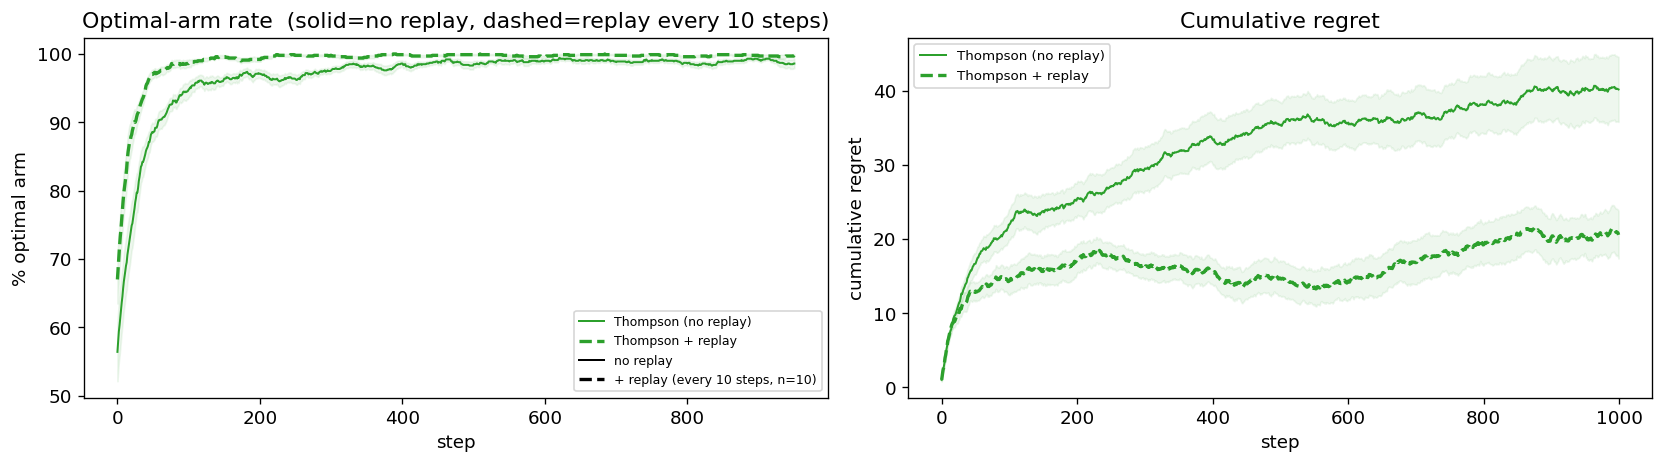

In [51]:
REPLAY_STYLES = {
    "BQL (no replay)":    ("C0", "-",  1.2),
    "BQL A+B (no replay)":("C1", "-",  1.2),
    "Thompson (no replay)":("C2","-",  1.2),
    "BQL + replay":        ("C0", "--", 2.0),
    "BQL A+B + replay":    ("C1", "--", 2.0),
    "Thompson + replay":   ("C2", "--", 2.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, data in replay_results.items():
    color, ls, lw = REPLAY_STYLES[name]
    r   = data["rewards"]
    opt = data["optimal"]

    def smooth(x): return np.convolve(x, np.ones(WINDOW)/WINDOW, mode="valid")
    opt_sm  = np.array([smooth(row) for row in opt]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, color=color, ls=ls, lw=lw, label=name)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt, color=color, alpha=0.08)

    cum_reg = (MEANS[OPT] - r).cumsum(1)
    mu_reg  = cum_reg.mean(0)
    sem_reg = cum_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_reg, color=color, ls=ls, lw=lw, label=name)
    axes[1].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg,
                         color=color, alpha=0.08)

for ax in axes:
    ax.legend(fontsize=8)
axes[0].set(xlabel="step", ylabel="% optimal arm",
            title=f"Optimal-arm rate  (solid=no replay, dashed=replay every {REPLAY_EVERY} steps)")
axes[1].set(xlabel="step", ylabel="cumulative regret",
            title="Cumulative regret")

# add a legend note for replay
from matplotlib.lines import Line2D
extra = [Line2D([0], [0], color="k", ls="-",  lw=1.2, label="no replay"),
         Line2D([0], [0], color="k", ls="--", lw=2.0, label=f"+ replay (every {REPLAY_EVERY} steps, n={REPLAY_N})")]
axes[0].legend(handles=axes[0].get_legend_handles_labels()[0] + extra, fontsize=7.5)

plt.tight_layout()
plt.show()

## Prioritized replay: pluggable priority schemes

In [52]:
from replay_buffer import PrioritizedReplayBuffer, Experience


# ---------------------------------------------------------------------------
# Priority functions — each is a callable (Experience) -> float.
# Agent-dependent ones close over the agent passed at construction.
# ---------------------------------------------------------------------------

class UniformPriority:
    """Constant priority → recovers standard uniform replay."""
    def __call__(self, exp: Experience) -> float:
        return 1.0


class TDErrorPriority:
    """Priority = |TD error| = |reward − posterior mean Q(s, a)|.

    Evaluated at push time (before the online update) so it reflects the
    agent's actual prediction error for that transition.
    """
    def __init__(self, agent, gamma: float = 0.0):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, exp: Experience) -> float:
        if exp.done or self.gamma == 0.0:
            target = exp.reward
        else:
            target = exp.reward + self.gamma * float(
                np.max(self.agent.q_means(exp.next_state)))
        return abs(target - self.agent.q_params(exp.state, exp.action).mean)


class UncertaintyPriority:
    """Priority = posterior scale of Q(s, a).

    Arms with wider posteriors (less explored) are sampled more often,
    directing replay toward reducing epistemic uncertainty first.
    """
    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        return self.agent.q_params(exp.state, exp.action).scale


class VPIPriority:
    """Priority = VPI bonus of the (s, a) pair.  BQL-only.

    Focuses replay on transitions that currently carry the highest value
    of perfect information, aligning replay with VPI-based action selection.
    """
    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        return self.agent.vpi(exp.state, exp.action)


print("Priority functions defined: UniformPriority, TDErrorPriority, "
      "UncertaintyPriority, VPIPriority")

Priority functions defined: UniformPriority, TDErrorPriority, UncertaintyPriority, VPIPriority


In [53]:
def run_bandit_with_buffer(agent, env: NoisyBandit, n_steps: int,
                           buf, replay_every: int, replay_n: int):
    """Training loop that accepts any buffer (ReplayBuffer or PrioritizedReplayBuffer).

    Experiences are pushed to the buffer BEFORE the online agent update so that
    agent-dependent priority functions (TD-error, uncertainty, VPI) capture the
    pre-update agent state — i.e. the true prediction error for that transition.
    """
    state = env.reset()
    opt   = env.optimal_action

    rewards      = np.zeros(n_steps)
    actions      = np.zeros(n_steps, dtype=int)
    optimal_hits = np.zeros(n_steps, dtype=bool)

    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)

        buf.push(state, a, r, next_state, done)   # priority uses pre-update agent
        agent.update(state, a, r, next_state, done)

        if (t + 1) % replay_every == 0 and len(buf) > 0:
            buf.replay_into(agent, replay_n)

        rewards[t]      = r
        actions[t]      = a
        optimal_hits[t] = (a == opt)
        state           = next_state

    return rewards, actions, optimal_hits

In [54]:
# Priority schemes to compare, each as (label, make_buffer_fn).
# make_buffer_fn receives the already-constructed agent so agent-dependent
# priority functions can close over it.
PRIORITY_SCHEMES = {
    "Uniform":      lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY, UniformPriority()),
    "TD error":     lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY, TDErrorPriority(agent)),
    "Uncertainty":  lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY, UncertaintyPriority(agent)),
    "VPI":          lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY, VPIPriority(agent)),
}

# Run BQL (Fix A+B) with each priority scheme
priority_results = {}

for scheme, make_buf in PRIORITY_SCHEMES.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = BQLRandomTies(n_states=1, n_actions=K, gamma=0.0, mu0=2.0)
        buf   = make_buf(agent)
        r, _, opt_hits = run_bandit_with_buffer(
            agent, env, N_STEPS, buf, REPLAY_EVERY, REPLAY_N)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))

    priority_results[scheme] = {
        "rewards": np.array(all_r),
        "optimal": np.array(all_opt),
    }
    mean_o  = priority_results[scheme]["optimal"].mean() * 100
    cum_reg = (MEANS[OPT] - priority_results[scheme]["rewards"]).sum(1).mean()
    print(f"{scheme:<14}  optimal%={mean_o:.1f}  cumulative regret={cum_reg:.1f}")

Uniform         optimal%=94.0  cumulative regret=30.9
TD error        optimal%=94.2  cumulative regret=34.5
Uncertainty     optimal%=98.8  cumulative regret=13.9
VPI             optimal%=89.2  cumulative regret=64.2


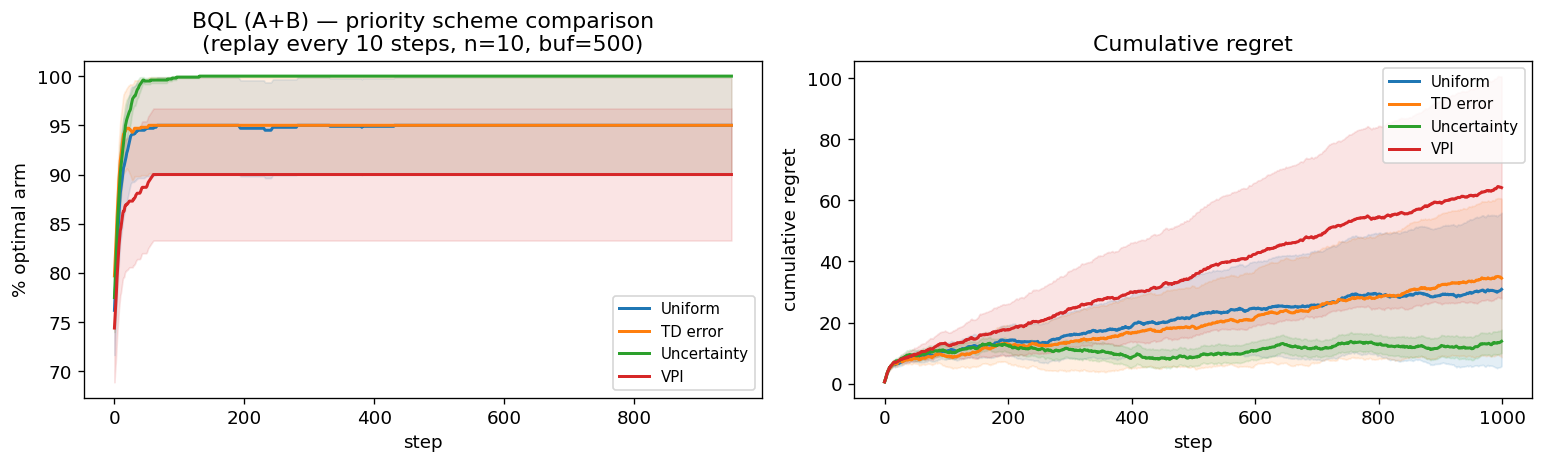

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (scheme, data) in enumerate(priority_results.items()):
    r   = data["rewards"]
    opt = data["optimal"]

    def smooth(x): return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")
    opt_sm  = np.array([smooth(row) for row in opt]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, label=scheme, color=f"C{i}", lw=1.8)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt,
                         color=f"C{i}", alpha=0.12)

    cum_reg = (MEANS[OPT] - r).cumsum(1)
    mu_reg  = cum_reg.mean(0)
    sem_reg = cum_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_reg, label=scheme, color=f"C{i}", lw=1.8)
    axes[1].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg,
                         color=f"C{i}", alpha=0.12)

axes[0].set(xlabel="step", ylabel="% optimal arm",
            title=f"BQL (A+B) — priority scheme comparison\n"
                  f"(replay every {REPLAY_EVERY} steps, n={REPLAY_N}, buf={BUF_CAPACITY})")
axes[1].set(xlabel="step", ylabel="cumulative regret", title="Cumulative regret")
for ax in axes:
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Expected Value of Backup (EVB)

EVB = GAIN × NEED  (Mattar & Daw, 2018)

**GAIN(s, a, r, s')**: expected improvement in V(s) = max_a E[Q(s,a)] from one
conjugate update with this experience.  Rather than running the full update,
we predict the new posterior mean analytically:

    μ_after = (λ·μ + T) / (λ + 1),   T = r + γ · max_{a'} E[Q(s',a')]
    GAIN    = max(0,  max(μ_after, max_{a'≠a} μ_{a',s})  −  V(s))

Clipped at zero: only experiences that (would) improve the greedy value get
elevated priority, mirroring the original paper.

**NEED(s)**: expected future γ-discounted visits to s under the current policy
(on-policy successor representation).  For the bandit with a single state and
γ=0, NEED = 1 everywhere and EVB reduces to GAIN.  A `need_fn` callable can
be passed for multi-state environments.

**Interaction with optimistic initialisation (μ₀ = 2.0)**: when unexplored
arms sit at mean 2.0 and typical rewards are < 2.0, any replay observation
leaves V(s) = 2.0 unchanged → GAIN = 0 → EVB ≈ uniform.  EVB is most
informative with a neutral prior (μ₀ = 0) where the greedy arm can actually
be changed by a single backup.

In [56]:
class EVBPriority:
    """Expected Value of Backup priority (Mattar & Daw, 2018).

    EVB(exp) = GAIN(exp) * NEED(exp.state)

    GAIN is computed analytically from the conjugate update formula —
    no actual posterior update is performed at push time.

    Args:
        agent:    BayesianQLearning instance (closed over by reference so
                  priorities reflect the agent state at the moment push() is
                  called, i.e. pre-update on that experience).
        gamma:    discount factor; use 0.0 for the bandit.
        need_fn:  optional callable (state: int) -> float for the NEED term.
                  Defaults to 1 everywhere (correct for single-state bandit).
                  For MDPs pass a successor-representation-based function.
    """

    def __init__(self, agent, gamma: float = 0.0, need_fn=None):
        self.agent   = agent
        self.gamma   = gamma
        self._need_fn = need_fn

    # ------------------------------------------------------------------

    def gain(self, exp: Experience) -> float:
        s, a, r, s_next, done = exp

        means    = self.agent.q_means(s)          # current posterior means
        v_before = float(np.max(means))

        # TD target (moment-matching bootstrap, same as BQL update rule)
        if done or self.gamma == 0.0:
            T = r
        else:
            T = r + self.gamma * float(np.max(self.agent.q_means(s_next)))

        # Predicted new posterior mean after one conjugate update — no side effects
        ng       = self.agent.q_params(s, a)
        mu_after = (ng.lam * ng.mu + T) / (ng.lam + 1.0)

        # New V(s) if only Q(s, a) were updated
        means_after    = means.copy()
        means_after[a] = mu_after
        v_after        = float(np.max(means_after))

        return max(0.0, v_after - v_before)

    def need(self, state: int) -> float:
        return 1.0 if self._need_fn is None else float(self._need_fn(state))

    def __call__(self, exp: Experience) -> float:
        return self.gain(exp) * self.need(exp.state)

In [57]:
# Compare all five priority schemes on BQL with default prior (mu0=0).
# mu0=0 is required for EVB: with optimistic mu0=2.0 the unexplored-arm
# frontier keeps V(s)=2.0 fixed and GAIN collapses to 0 for all experiences.

ALL_PRIORITY_SCHEMES = {
    "Uniform":     lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY,
                                     UniformPriority()),
    "TD error":    lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY,
                                     TDErrorPriority(agent)),
    "Uncertainty": lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY,
                                     UncertaintyPriority(agent)),
    "VPI":         lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY,
                                     VPIPriority(agent)),
    "EVB":         lambda agent: PrioritizedReplayBuffer(BUF_CAPACITY,
                                     EVBPriority(agent, gamma=0.0)),
}

evb_results = {}

for scheme, make_buf in ALL_PRIORITY_SCHEMES.items():
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        # mu0=0: neutral prior so GAIN is non-trivial for EVB
        agent = BQLRandomTies(n_states=1, n_actions=K, gamma=0.0,
                              mu0=0.0, lam0=1.0, alpha0=1.0, beta0=1.0)
        buf = make_buf(agent)
        r, _, opt_hits = run_bandit_with_buffer(
            agent, env, N_STEPS, buf, REPLAY_EVERY, REPLAY_N)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))

    evb_results[scheme] = {
        "rewards": np.array(all_r),
        "optimal": np.array(all_opt),
    }
    mean_o  = evb_results[scheme]["optimal"].mean() * 100
    cum_reg = (MEANS[OPT] - evb_results[scheme]["rewards"]).sum(1).mean()
    print(f"{scheme:<14}  optimal%={mean_o:.1f}  cumulative regret={cum_reg:.1f}")

Uniform         optimal%=54.3  cumulative regret=307.6
TD error        optimal%=59.0  cumulative regret=272.4
Uncertainty     optimal%=49.9  cumulative regret=370.0
VPI             optimal%=49.9  cumulative regret=364.8
EVB             optimal%=49.9  cumulative regret=371.3


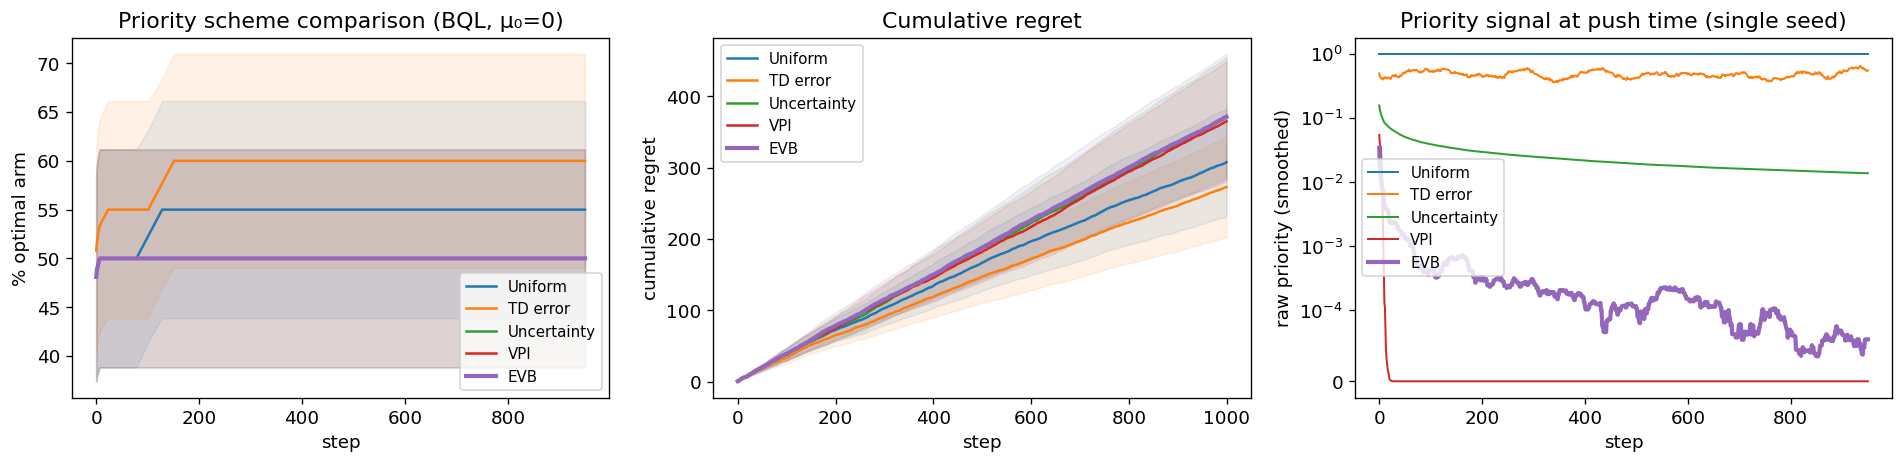

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (scheme, data) in enumerate(evb_results.items()):
    r   = data["rewards"]
    opt = data["optimal"]
    lw  = 2.5 if scheme == "EVB" else 1.5
    zo  = 3   if scheme == "EVB" else 2

    def smooth(x): return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")
    opt_sm  = np.array([smooth(row) for row in opt]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, label=scheme, color=f"C{i}", lw=lw, zorder=zo)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt,
                         color=f"C{i}", alpha=0.10)

    cum_reg = (MEANS[OPT] - r).cumsum(1)
    mu_reg  = cum_reg.mean(0)
    sem_reg = cum_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_reg, label=scheme, color=f"C{i}", lw=lw, zorder=zo)
    axes[1].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg,
                         color=f"C{i}", alpha=0.10)

axes[0].set(xlabel="step", ylabel="% optimal arm",
            title="Priority scheme comparison (BQL, μ₀=0)")
axes[1].set(xlabel="step", ylabel="cumulative regret", title="Cumulative regret")
for ax in axes[:2]:
    ax.legend(fontsize=9)

# --- panel 3: GAIN distribution across schemes (single seed, logged at push time)
np.random.seed(0)
gain_traces = {}
for scheme, make_buf in ALL_PRIORITY_SCHEMES.items():
    agent  = BQLRandomTies(n_states=1, n_actions=K, gamma=0.0)
    buf    = make_buf(agent)
    gains  = []
    state  = env.reset()
    for t in range(N_STEPS):
        a = agent.select_action(state)
        _, r_t, done, _ = env.step(a)
        exp = Experience(state, a, r_t, state, done)
        # record raw priority before push
        p = buf.priority_fn(exp)
        gains.append(p)
        buf.push(state, a, r_t, state, done)
        agent.update(state, a, r_t, state, done)
        if (t + 1) % REPLAY_EVERY == 0 and len(buf) > 0:
            buf.replay_into(agent, REPLAY_N)
    gain_traces[scheme] = np.array(gains)

def smooth(x): return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")
steps_g = np.arange(len(smooth(gain_traces["EVB"])))
for i, (scheme, g) in enumerate(gain_traces.items()):
    lw = 2.5 if scheme == "EVB" else 1.2
    axes[2].plot(steps_g, smooth(g), label=scheme, color=f"C{i}", lw=lw)
axes[2].set(xlabel="step", ylabel="raw priority (smoothed)",
            title="Priority signal at push time (single seed)")
axes[2].set_yscale("symlog", linthresh=1e-4)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Extended ablation: BQL variants + EVB prioritized replay

In [59]:
# Two EVB replay variants to slot into the ablation:
#
#  • BQL A+B + EVB  (mu0=2.0, same prior as the rest of the ablation)
#    EVB GAIN≈0 here because the optimistic frontier keeps V(s)=2.0 until all
#    arms are explored → effectively degrades to uniform replay.
#
#  • BQL A + EVB  (mu0=0, neutral prior)
#    GAIN is non-trivial from the start; shows EVB at its best.

evb_ablation = {}

for label, mu0 in [("BQL A+B + EVB replay (μ₀=2)", 2.0),
                   ("BQL A   + EVB replay (μ₀=0)", 0.0)]:
    all_r, all_opt = [], []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = BQLRandomTies(n_states=1, n_actions=K, gamma=0.0, mu0=mu0)
        buf   = PrioritizedReplayBuffer(BUF_CAPACITY, EVBPriority(agent, gamma=0.0))
        r, _, opt_hits = run_bandit_with_buffer(
            agent, env, N_STEPS, buf, REPLAY_EVERY, REPLAY_N)
        all_r.append(r)
        all_opt.append(opt_hits.astype(float))
    evb_ablation[label] = {"rewards": np.array(all_r), "optimal": np.array(all_opt)}
    mean_o  = evb_ablation[label]["optimal"].mean() * 100
    cum_reg = (MEANS[OPT] - evb_ablation[label]["rewards"]).sum(1).mean()
    print(f"{label:<42}  optimal%={mean_o:.1f}  cumulative regret={cum_reg:.1f}")

BQL A+B + EVB replay (μ₀=2)                 optimal%=91.9  cumulative regret=49.7
BQL A   + EVB replay (μ₀=0)                 optimal%=49.9  cumulative regret=371.3


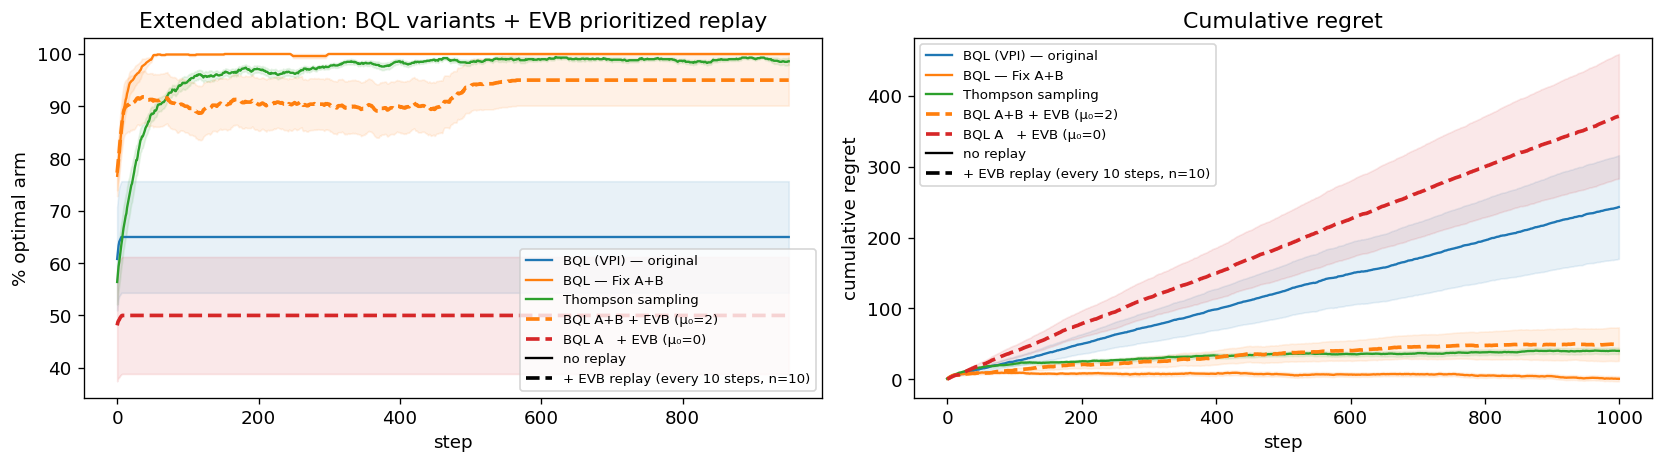

In [60]:
# Pull the key baselines from fixed_results and merge with EVB entries.
ABLATION_ENTRIES = [
    ("BQL (VPI) — original",  fixed_results["BQL (VPI) — original"],  "C0", "-",  1.4),
    ("BQL — Fix A+B",          fixed_results["BQL — Fix A+B"],         "C1", "-",  1.4),
    ("Thompson sampling",      fixed_results["Thompson sampling"],      "C2", "-",  1.4),
    ("BQL A+B + EVB (μ₀=2)",  evb_ablation["BQL A+B + EVB replay (μ₀=2)"], "C1", "--", 2.2),
    ("BQL A   + EVB (μ₀=0)",  evb_ablation["BQL A   + EVB replay (μ₀=0)"], "C3", "--", 2.2),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, data, color, ls, lw in ABLATION_ENTRIES:
    r   = data["rewards"]
    opt = data["optimal"]

    def smooth(x): return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")
    opt_sm  = np.array([smooth(row) for row in opt]) * 100
    steps   = np.arange(opt_sm.shape[1])
    mu_opt  = opt_sm.mean(0)
    sem_opt = opt_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu_opt, label=label, color=color, ls=ls, lw=lw)
    axes[0].fill_between(steps, mu_opt - sem_opt, mu_opt + sem_opt,
                         color=color, alpha=0.10)

    cum_reg = (MEANS[OPT] - r).cumsum(1)
    mu_reg  = cum_reg.mean(0)
    sem_reg = cum_reg.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_reg, label=label, color=color, ls=ls, lw=lw)
    axes[1].fill_between(np.arange(N_STEPS), mu_reg - sem_reg, mu_reg + sem_reg,
                         color=color, alpha=0.10)

from matplotlib.lines import Line2D
legend_extras = [
    Line2D([0],[0], color="k", ls="-",  lw=1.4, label="no replay"),
    Line2D([0],[0], color="k", ls="--", lw=2.2,
           label=f"+ EVB replay (every {REPLAY_EVERY} steps, n={REPLAY_N})"),
]
axes[0].set(xlabel="step", ylabel="% optimal arm",
            title="Extended ablation: BQL variants + EVB prioritized replay")
axes[1].set(xlabel="step", ylabel="cumulative regret", title="Cumulative regret")
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + legend_extras, labels + [h.get_label() for h in legend_extras],
              fontsize=8)

plt.tight_layout()
plt.show()